<style>
pre {
    page-break-inside: avoid;
    font-size: 10px;
}
</style>

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
import pandas as pd

df = pd.read_parquet("Crime_Data_from_2020_to_Present.parquet")
df.head(5)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,occ_year,occ_month,occ_date,occ_day
0,211507896,2021-04-11,2020-11-07,08:45:00,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,7800 BEEMAN AV,34.2124,-118.4092,2020,Nov,7,Sat
1,201516622,2020-10-21,2020-10-18,18:45:00,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",...,IC,Invest Cont,230.0,ATOLL AV,34.1993,-118.4203,2020,Oct,18,Sun
2,240913563,2024-12-10,2020-10-30,12:40:00,9,Van Nuys,933,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,14600 SYLVAN ST,34.1847,-118.4509,2020,Oct,30,Fri
3,210704711,2020-12-24,2020-12-24,13:10:00,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,...,IC,Invest Cont,331.0,6000 COMEY AV,34.0339,-118.3747,2020,Dec,24,Thu
4,201418201,2020-10-03,2020-09-29,18:30:00,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),...,IC,Invest Cont,420.0,4700 LA VILLA MARINA,33.9813,-118.4350,2020,Sep,29,Tue


In [10]:
# Osnovne informacije o kolonama i tipovima podataka
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1004991 entries, 0 to 1004990
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   DR_NO           1004991 non-null  int64         
 1   Date Rptd       1004991 non-null  datetime64[ns]
 2   DATE OCC        1004991 non-null  datetime64[ns]
 3   TIME OCC        1004991 non-null  object        
 4   AREA            1004991 non-null  int64         
 5   AREA NAME       1004991 non-null  str           
 6   Rpt Dist No     1004991 non-null  int64         
 7   Part 1-2        1004991 non-null  int64         
 8   Crm Cd          1004991 non-null  int64         
 9   Crm Cd Desc     1004991 non-null  str           
 10  Mocodes         1004991 non-null  str           
 11  Vict Age        1004991 non-null  int64         
 12  Vict Sex        1004991 non-null  str           
 13  Vict Descent    1004991 non-null  str           
 14  Premis Cd       1004991 non-n

Ovaj skup podataka bilježi kriminalne incidente s detaljima o vrsti zločina, lokaciji i žrtvama
Cilj je predvidjeti tip zločina koristeći dostupne značajke

In [11]:
# Broj null vrijednosti po koloni
df.isnull().sum()

DR_NO             0
Date Rptd         0
DATE OCC          0
TIME OCC          0
AREA              0
AREA NAME         0
Rpt Dist No       0
Part 1-2          0
Crm Cd            0
Crm Cd Desc       0
Mocodes           0
Vict Age          0
Vict Sex          0
Vict Descent      0
Premis Cd         0
Premis Desc       0
Weapon Used Cd    0
Weapon Desc       0
Status            0
Status Desc       0
Crm Cd 1          0
LOCATION          0
LAT               0
LON               0
occ_year          0
occ_month         0
occ_date          0
occ_day           0
dtype: int64

U skupu podataka nema null vrijednosti, sve kolone su potpuno popunjene, šta znači da nije potrebna dodatna obrada zbog nedostajućih podataka

In [12]:
from sklearn.preprocessing import StandardScaler

y = df['Part 1-2'] 

X = df[['Vict Age', 'Vict Sex', 'Vict Descent', 'AREA']]

# Enkodiranje kategorijskih varijabli
X = pd.get_dummies(X, drop_first=True)

# Skaliranje numeričkih feature-a
scaler = StandardScaler()
X[['Vict Age', 'AREA']] = scaler.fit_transform(X[['Vict Age', 'AREA']])

In [13]:
X.head()

,Vict Age,AREA,Vict Sex_Male,Vict Sex_Transgender/Other,Vict Sex_Unknown,Vict Descent_Asian Indian,Vict Descent_Black,Vict Descent_Cambodian,Vict Descent_Chinese,Vict Descent_Filipino,...,Vict Descent_Korean,Vict Descent_Laotian,Vict Descent_Not Specified,Vict Descent_Other,Vict Descent_Other Asian,Vict Descent_Pacific Islander,Vict Descent_Samoan,Vict Descent_Unknown,Vict Descent_Vietnamese,Vict Descent_White
0,0.094710,0.705087,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.140180,0.705087,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.049241,-0.276869,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0.822224,-0.604188,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,1.549738,0.541428,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Ovdje se podaci pripremaju za model: 
kategorijske varijable(Vict Sex, Vict Descent) se pretvaraju u numeričke kolone (True/False),
a numeričke varijable (Vict Age, AREA) se skaliraju da imaju prosjek 0 i standardnu devijaciju 1
To omogućuje modelu da pravilno uči

In [14]:
X.shape
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1004991 entries, 0 to 1004990
Data columns (total 24 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   Vict Age                             1004991 non-null  float64
 1   AREA                                 1004991 non-null  float64
 2   Vict Sex_Male                        1004991 non-null  bool   
 3   Vict Sex_Transgender/Other           1004991 non-null  bool   
 4   Vict Sex_Unknown                     1004991 non-null  bool   
 5   Vict Descent_Asian Indian            1004991 non-null  bool   
 6   Vict Descent_Black                   1004991 non-null  bool   
 7   Vict Descent_Cambodian               1004991 non-null  bool   
 8   Vict Descent_Chinese                 1004991 non-null  bool   
 9   Vict Descent_Filipino                1004991 non-null  bool   
 10  Vict Descent_Guamanian               1004991 non-null  bool   
 11  Vict Desc

X ima 1.004.991 reda i 24 kolone
Podaci su spremni za model: numeričke kolone su skalirane, a kategorijske enkodirane
Sljedeći korak je podjela na trening i test te treniranje modela

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.65, shuffle=False)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (653244, 24)
X_test: (351747, 24)
y_train: (653244,)
y_test: (351747,)


Ovdje se skup podataka dijeli na trening i test skup, 65% podataka ide za učenje, a 35% za testiranje

Ovdje se model logističke regresije trenira na trening skupu, a zatim provjerava na test skupu
Model je postigao točnost od oko 66%, a matrica zabune i klasifikacijski izvještaj pokazuju kako dobro predviđa obje klase
Grafikon matrice zabune vizualno prikazuje stvarne i predviđene vrijednosti

Točnost modela: 0.6591754869266832
Matrica zabune:
 [[173238  49605]
 [ 70279  58625]]
Klasifikacijski izvještaj:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74    222843
           1       0.54      0.45      0.49    128904

    accuracy                           0.66    351747
   macro avg       0.63      0.62      0.62    351747
weighted avg       0.65      0.66      0.65    351747



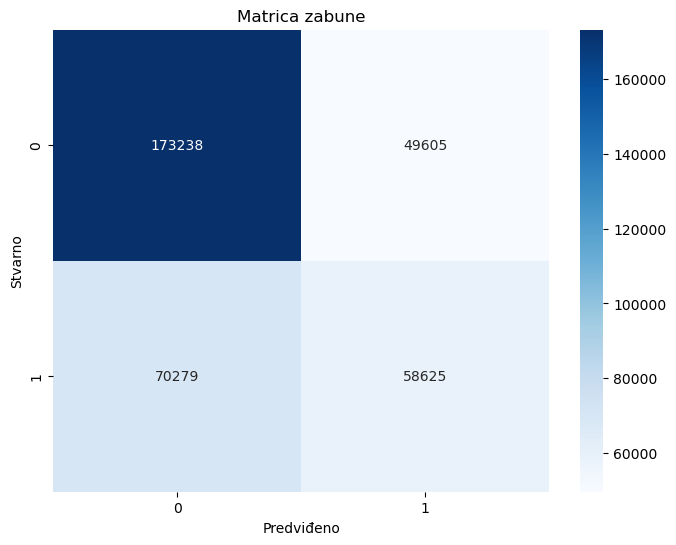

In [24]:
# Treniranje modela
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predikcija na test skupu
y_pred = model.predict(X_test)

# Evaluacija
print("Točnost modela:", accuracy_score(y_test, y_pred))
print("Matrica zabune:\n", confusion_matrix(y_test, y_pred))
print("Klasifikacijski izvještaj:\n", classification_report(y_test, y_pred))

#Vizualizacija matrice zabune
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predviđeno")
plt.ylabel("Stvarno")
plt.title("Matrica zabune")
plt.show()

ROC krivulja pokazuje koliko dobro naš model razlikuje dvije klase
Na x-osi je stopa lažno pozitivnih (koliko puta model pogrešno predvidi klasu 1), 
a na y-osi stopa istinski pozitivnih (koliko puta model ispravno predvidi klasu 1)

Linija narančaste boje je ROC krivulja našeg modela, 
a plava isprekidana linija predstavlja nasumično predviđanje

AUC = 0,68 znači da model umjereno dobro razlikuje klase, 
bolje nego slučajno, ali nije savršen

Šta je krivulja bliža gornjem lijevom kutu i AUC veći, to je model precizniji

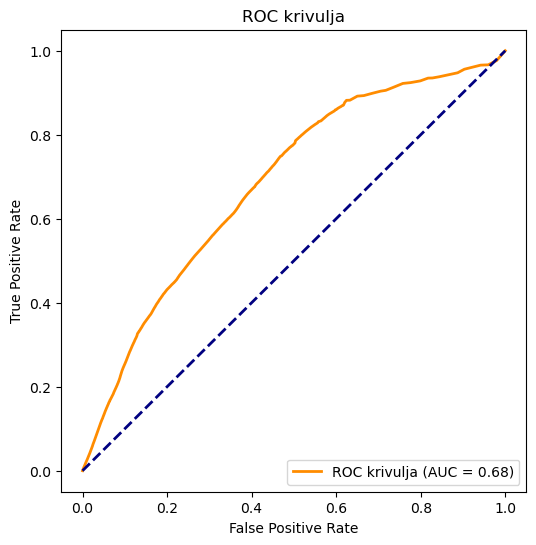

In [23]:
# Pretvaranje 1 -> 0, 2 -> 1
y_binary = y.map({1: 0, 2: 1})

# Isto podjela na train i test
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, train_size=0.65, shuffle=False)

# Treniranje modela
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predikcija vjerojatnosti
y_prob = model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC krivulja (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC krivulja')
plt.legend(loc="lower right")
plt.show()